In [5]:
 import pandas as pd
 import matplotlib.pyplot as plt
 import numpy as np
 import seaborn as sns


In [6]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
data = load_breast_cancer(as_frame=True)

In [ ]:
X = data.data
y = data.target

df = X # Assigning features to df to align with prior usage

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred=rf.predict(X_test)


In [ ]:
print("accuracy score:",accuracy_score(y_test,rf_pred))
print("\n Classification_report\n",classification_report(y_test,rf_pred))
print("\n Confusion_matrix\n",confusion_matrix(y_test,rf_pred))

accuracy score: 0.956140350877193

 Classification_report
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


 Confusion_matrix
 [[39  3]
 [ 2 70]]


In [ ]:
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)

In [ ]:
print("accuracy score:",accuracy_score(y_test,xgb_pred))
print("\n Classification_report\n",classification_report(y_test,xgb_pred))
print("\n Confusion_matrix\n",confusion_matrix(y_test,xgb_pred))

accuracy score: 0.956140350877193

 Classification_report
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


 Confusion_matrix
 [[38  4]
 [ 1 71]]


In [ ]:
lightgbm=LGBMClassifier()
lightgbm.fit(X_train,y_train)
lightgbm_pred=lightgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
print("accuracy score:",accuracy_score(y_test,lightgbm_pred))
print("\n Classification_report\n",classification_report(y_test,lightgbm_pred))
print("\n Confusion_matrix\n",confusion_matrix(y_test,lightgbm_pred))

accuracy score: 0.9649122807017544

 Classification_report
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


 Confusion_matrix
 [[39  3]
 [ 1 71]]


In [ ]:
comparision=pd.DataFrame({
    "model":[
        "RandomForestClassifier","XGBClassifier","LGBMClassifier"
    ],
    "accuracy_score":[
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,lightgbm_pred)
    ],
    "precision":[
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred),
        precision_score(y_test,lightgbm_pred)
    ],
    "recall":[
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred),
        recall_score(y_test,lightgbm_pred)
    ],
    "f1_score":[
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred),
        f1_score(y_test,lightgbm_pred)
    ]
})

In [ ]:
comparision

,model,accuracy_score,precision,recall,f1_score
0,RandomForestClassifier,0.956140,0.958904,0.972222,0.965517
1,XGBClassifier,0.956140,0.946667,0.986111,0.965986
2,LGBMClassifier,0.964912,0.959459,0.986111,0.972603


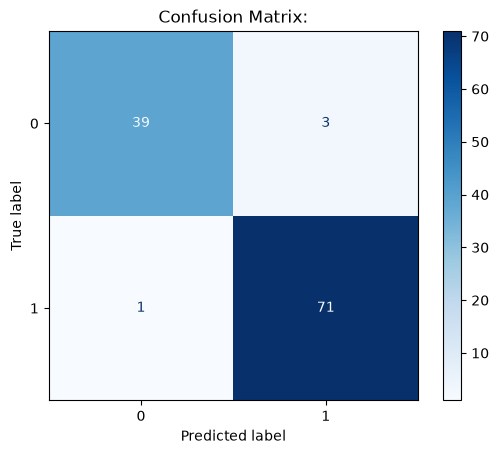

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lightgbm_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix:")
plt.show()

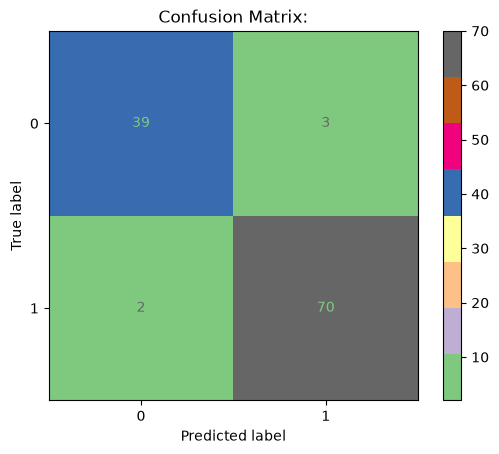

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, rf_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Accent')
plt.title("Confusion Matrix:")
plt.show()

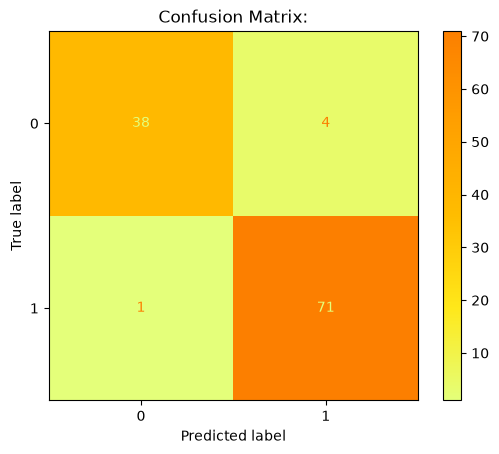

In [ ]:
cm = confusion_matrix(y_test,xgb_pred )
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Wistia')
plt.title("Confusion Matrix:")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = xgb.predict(X_test)

y_prob=xgb.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test,y_prob)

print(roc_score)

0.9927248677248677


In [ ]:
y_pred = lightgbm.predict(X_test)

y_prob=lightgbm.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test,y_prob)

print(roc_score)

0.9897486772486772


In [ ]:
y_pred = rf.predict(X_test)

y_prob=rf.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test,y_prob)

print(roc_score)

0.9937169312169312


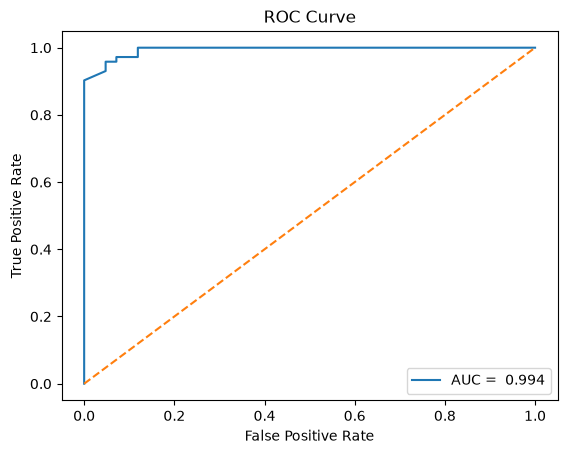

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.plot(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC =  {roc_score:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
!pip install optuna

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model= XGBClassifier(random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print("Accuracy",accuracy_score(y_test,y_pred))

param_grid={
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,4,5]
}
grid=GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3
)
grid.fit(X_train,y_train)
print("Best Parameters:",grid.best_params_)
best_model=grid.best_estimator_
prediction=best_model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,prediction))

Accuracy 0.956140350877193


C:\Users\Exam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.9473684210526315


In [ ]:
random_params={
    'n_estimators':[50,100,150,200],
    'max_depth':[3,4,5,6,7],
    'learning_rate':[0.01,0.1,0.2,0.3]
}
random_search=RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_distributions=random_params,
    n_iter =10,
    cv=3,
    random_state=42
)
random_search.fit(X_train,y_train)
print("Best Parameters:",random_search.best_params_)
best_random = random_search.best_estimator_
prediction=best_random.predict(X_test)
print("Accuracy:",accuracy_score(y_test,prediction))


Best Parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1}
Accuracy: 0.9473684210526315


In [ ]:
import optuna
def objective(trial):
  model=XGBClassifier(
      n_estimators=trial.suggest_int("n_estimators",50,200),
      max_depth=trial.suggest_int("max_depth",3,7),
      learning_rate=trial.suggest_float("learning_rate",0.01,0.2),
      random_state=42
  )
  model.fit(X_train,y_train)
  prediction=model.predict(X_test)
  return accuracy_score(y_test,prediction)
study=optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=20)
print(study.best_params)
best_model=XGBClassifier(
**study.best_params,
random_state=42
)
best_model.fit(X_train,y_train)
prediction=best_model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,prediction))


[I 2026-07-02 16:17:53,761] A new study created in memory with name: no-name-c2b62a8f-b9a8-4741-a1a5-a95b120e89a1


[I 2026-07-02 16:17:53,811] Trial 0 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 156, 'max_depth': 6, 'learning_rate': 0.16780726259697182}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:53,841] Trial 1 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 97, 'max_depth': 3, 'learning_rate': 0.10860044236311754}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:53,899] Trial 2 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 171, 'max_depth': 4, 'learning_rate': 0.020017398948371297}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:53,929] Trial 3 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 55, 'max_depth': 5, 'learning_rate': 0.14352691443855725}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:53,966] Trial 4 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 109, 'max_depth': 7, 'learning_rate': 0.13482932171813722}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:54,001] Trial 5 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 118, 'max_depth': 4, 'learning_rate': 0.1559874024222208}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:54,040] Trial 6 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 79, 'max_depth': 7, 'learning_rate': 0.06802945781345957}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:54,094] Trial 7 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 190, 'max_depth': 7, 'learning_rate': 0.09469994639904537}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:54,125] Trial 8 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 58, 'max_depth': 6, 'learning_rate': 0.10454348094313602}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:54,174] Trial 9 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 94, 'max_depth': 7, 'learning_rate': 0.0210151016597612}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:54,236] Trial 10 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 147, 'max_depth': 5, 'learning_rate': 0.05927597026257515}. Best is trial 0 with value: 0.9473684210526315.


[I 2026-07-02 16:17:54,272] Trial 11 finished with value: 0.956140350877193 and parameters: {'n_estimators': 130, 'max_depth': 3, 'learning_rate': 0.18636010064630587}. Best is trial 11 with value: 0.956140350877193.


[I 2026-07-02 16:17:54,309] Trial 12 finished with value: 0.956140350877193 and parameters: {'n_estimators': 139, 'max_depth': 3, 'learning_rate': 0.19780784435037013}. Best is trial 11 with value: 0.956140350877193.


[I 2026-07-02 16:17:54,344] Trial 13 finished with value: 0.956140350877193 and parameters: {'n_estimators': 127, 'max_depth': 3, 'learning_rate': 0.19997863690231354}. Best is trial 11 with value: 0.956140350877193.


[I 2026-07-02 16:17:54,383] Trial 14 finished with value: 0.956140350877193 and parameters: {'n_estimators': 152, 'max_depth': 3, 'learning_rate': 0.19918946158209105}. Best is trial 11 with value: 0.956140350877193.


[I 2026-07-02 16:17:54,422] Trial 15 finished with value: 0.956140350877193 and parameters: {'n_estimators': 136, 'max_depth': 4, 'learning_rate': 0.17480659535905327}. Best is trial 11 with value: 0.956140350877193.


[I 2026-07-02 16:17:54,465] Trial 16 finished with value: 0.956140350877193 and parameters: {'n_estimators': 178, 'max_depth': 3, 'learning_rate': 0.1771393873767976}. Best is trial 11 with value: 0.956140350877193.


[I 2026-07-02 16:17:54,506] Trial 17 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 141, 'max_depth': 4, 'learning_rate': 0.18758536257945516}. Best is trial 11 with value: 0.956140350877193.


[I 2026-07-02 16:17:54,554] Trial 18 finished with value: 0.956140350877193 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.14233445443314907}. Best is trial 11 with value: 0.956140350877193.


[I 2026-07-02 16:17:54,602] Trial 19 finished with value: 0.9473684210526315 and parameters: {'n_estimators': 166, 'max_depth': 4, 'learning_rate': 0.12408122645743835}. Best is trial 11 with value: 0.956140350877193.


{'n_estimators': 130, 'max_depth': 3, 'learning_rate': 0.18636010064630587}
Accuracy: 0.956140350877193


In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
rus=RandomOverSampler(random_state=42)
X_sample,y_sample=rus.fit_resample(X_train,y_train)

In [ ]:
smote=SMOTE(random_state=42)
X_sample,y_sample=smote.fit_resample(X_train,y_train)
print(y_train.value_counts())
print(y_sample.value_counts())

target
1    285
0    170
Name: count, dtype: int64
target
1    285
0    285
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

model=DecisionTreeClassifier(class_weight="balanced")
model.fit(X_train, y_train)

ratio=len(y_train[y_train==0])/len(y_train[y_train==1])
model=XGBClassifier(scale_pos_weight=ratio, random_state=42)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
prob = model.predict_proba(X_test)[:,1]
thresholds=0.40
for threshold in [0.5,0.4,0.2]:
  predictions=(prob>=threshold).astype(int)
  print(precision_score(y_test,predictions))
  print(recall_score(y_test,predictions))
  print(f1_score(y_test,predictions))

0.9459459459459459
0.9722222222222222
0.958904109589041
0.9466666666666667
0.9861111111111112
0.9659863945578231
0.9466666666666667
0.9861111111111112
0.9659863945578231


In [ ]:
!pip install shap

'pip' is not recognized as an internal or external command,
operable program or batch file.


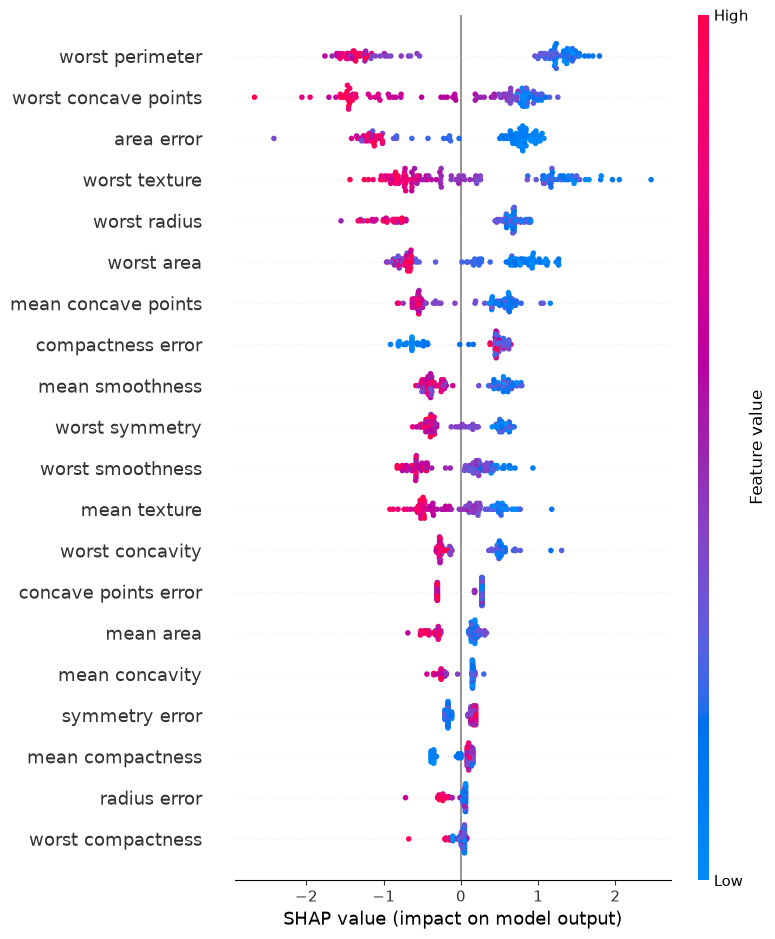

In [ ]:
import shap
explainer=shap.TreeExplainer(xgb)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test,feature_names=X.columns)

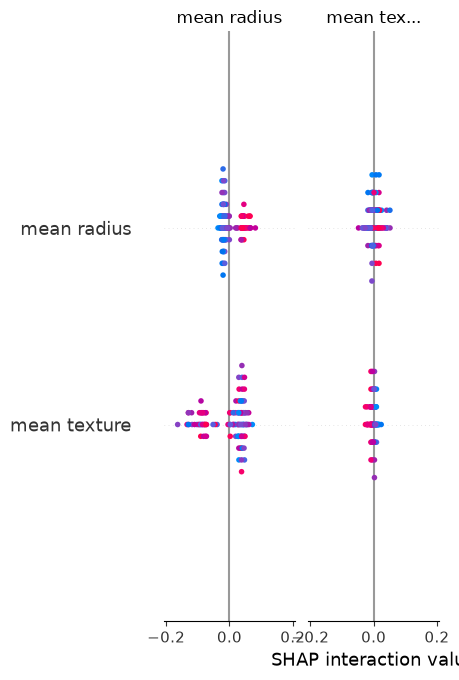

In [ ]:
import shap
explainer=shap.TreeExplainer(rf)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test,feature_names=X.columns)

C:\Users\Exam\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


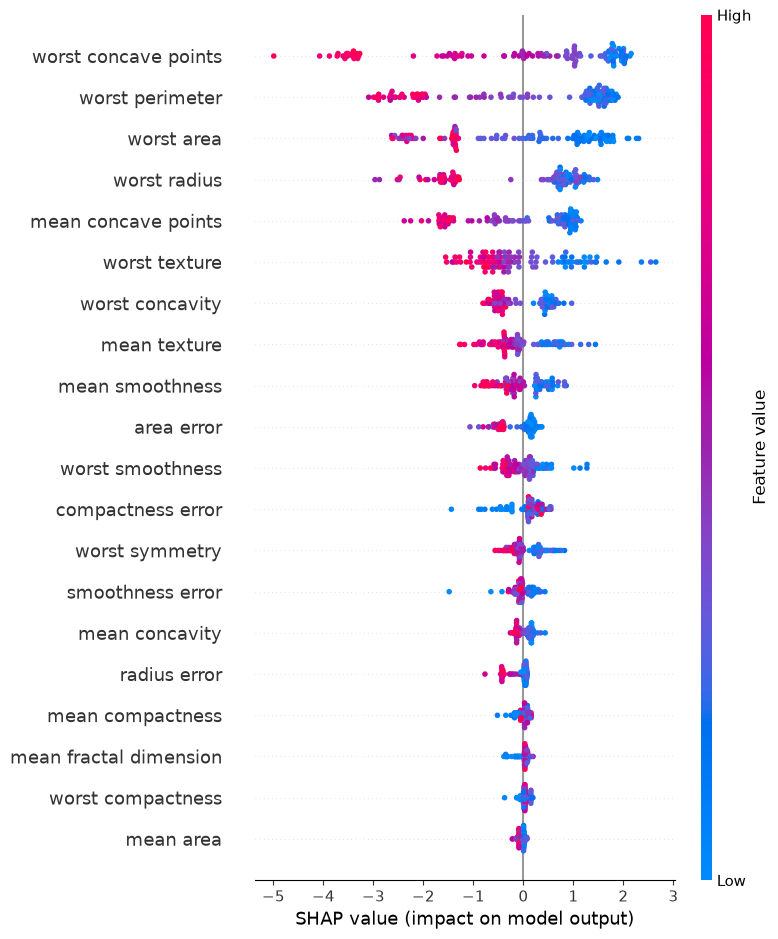

In [ ]:
import shap
explainer=shap.TreeExplainer(lightgbm)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test,feature_names=X.columns)

In [ ]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    feature_names=X.columns
)